## O danych

Zbiór opisuje aktywność ofert Airbnb w Nowym Jorku w 2019 roku. Zawiera informacje o lokalizacji ofert, typach pokojów, cenach, minimalnej liczbie nocy oraz popularności mierzonej liczbą recenzji.

Główne kolumny, z którymi będziemy działać:

* **neighbourhood_group** - Dzielnica główna (Manhattan, Brooklyn, Queens, Bronx, Staten Island).

* **neighbourhood** - Konkretne osiedle (np. Williamsburg, Harlem).

* **room_type** - Typ noclegu (Entire home/apt, Private room, Shared room).

* **price** - Cena za noc (w dolarach).

* **minimum_nights** - Minimalna długość rezerwacji.

* **number_of_reviews** i **reviews_per_month** - Metryki popularności oferty.

* **availability_365** - Liczba dni w roku, kiedy oferta jest dostępna do rezerwacji.




### Cel analizy i wprowadzenie

#### Głównym celem badania była identyfikacja, statystyczne uzasadnienie oraz biznesowa interpretacja anomalii cenowych (outliers) w ofertach Airbnb w Nowym Jorku. Zrozumienie punktów skrajnych jest kluczowym elementem inżynierii danych przed budowaniem modeli predykcyjnych (ML) lub raportów BI, ponieważ skrajne wartości drastycznie zniekształcają tradycyjne miary statystyczne (np. średnią arytmetyczną).

![Opis obrazka](https://cdn.britannica.com/70/20070-050-C2E2045C/Central-Park-Manhattan-New-York-City-apartment.jpg)

In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ustawienie formatu wyświetlania liczb zmiennoprzecinkowych na 2 miejsca po przecinku
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [3]:
# Ładowanie danych z pliku CSV do Pandas
df = pd.read_csv('AB_NYC_2019.csv')

In [4]:
# Wyświetlenie pierwszych 10 wierszy danych
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.75,-73.97,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.69,-73.96,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76,-73.98,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80,-73.97,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71,-73.99,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [5]:
# Wyświetlenie losowych 10 wierszy danych
df.sample(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
18369,14426680,Luxurious and Sunny 2 bed/2 bath home (1100 sqft),2678122,Tasha,Brooklyn,Williamsburg,40.72,-73.95,Entire home/apt,180,4,64,2019-06-06,2.00,3,57
26698,21213799,Nice room in Harlem,63417081,Devon,Manhattan,Harlem,40.82,-73.94,Private room,45,30,2,2018-12-31,0.10,8,261
19079,15159731,Executive Studio Best Location,61391963,Corporate Housing,Manhattan,Kips Bay,40.74,-73.98,Entire home/apt,117,30,9,2018-09-30,0.30,91,317
5257,3800549,Williamsburg Studio,810266,Jonathan,Brooklyn,Williamsburg,40.72,-73.96,Entire home/apt,125,21,1,2015-04-30,0.02,1,0
14838,11753116,Luxury Style Space: ideal for short or longterm!,50199714,Dellasie,Brooklyn,Crown Heights,40.67,-73.94,Private room,49,1,86,2019-06-10,2.16,1,4
28926,22291938,"Modern, Private Williamsburg Bedroom",83170219,Hannah,Brooklyn,Williamsburg,40.71,-73.94,Private room,60,2,1,2018-02-13,0.06,1,0
43262,33548323,Modern & Cozy Room with PRIVATE balcony!,6946537,Tiara,Brooklyn,Flatbush,40.63,-73.96,Private room,80,2,0,NaN,NaN,1,90
18747,14840286,Artist's Townhouse,9977688,Lenissima,Brooklyn,Bedford-Stuyvesant,40.69,-73.92,Entire home/apt,575,4,6,2018-12-31,0.19,1,179
19432,15500135,NYC Elegance steps 2 Central Park see all pict...,99552750,Wendy,Manhattan,Upper East Side,40.76,-73.97,Entire home/apt,190,4,83,2019-06-22,2.58,1,104
8290,6376606,"Gramercy Apt, Private Bedroom",33234599,Smit,Manhattan,Kips Bay,40.74,-73.98,Private room,64,3,4,2016-04-13,0.08,1,0


Brakujące wartości (liczba i %):
                   missing_count  missing_pct
last_review                10052        20.56
reviews_per_month          10052        20.56
host_name                     21         0.04
name                          16         0.03


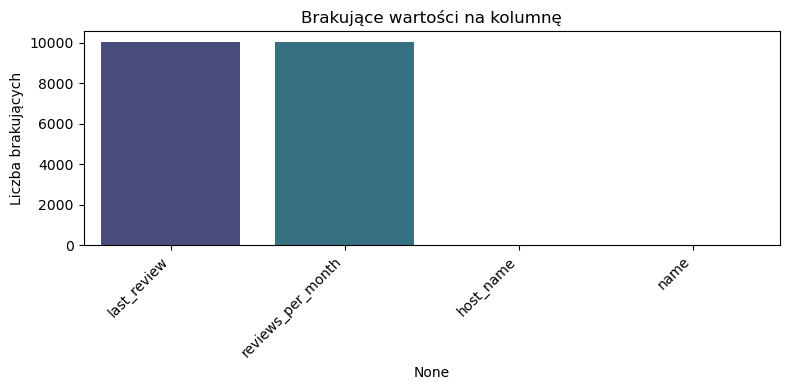

In [6]:
# Pokazanie brakujących danych w df: liczba i procent braków na kolumnę + wykres słupkowy
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)

if missing_df.empty:
    print("Brak brakujących danych.")
else:
    print("Brakujące wartości (liczba i %):")
    print(missing_df.to_string())
    # wykres tylko dla kolumn z brakami
    plt.figure(figsize=(8, 4))
    sns.barplot(x=missing_df.index, y='missing_count', data=missing_df.reset_index(), hue=missing_df.index, palette='viridis', legend=False)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Liczba brakujących')
    plt.title('Brakujące wartości na kolumnę')
    plt.tight_layout()
    plt.show()

In [7]:
# Rejestracja DataFrame w DuckDB
con = duckdb.connect(database=':memory:')
con.register('airbnb', df.astype(object)) # Rejestracja z konwersją do object, aby uniknąć problemów z typami danych

In [8]:
# Tworzymy widok "airbnb_clean", który zawiera wszystkie kolumny z tabeli "airbnb", ale z oczyszczonymi danymi. Dla kolumny "last_review" używamy funkcji COALESCE, aby zastąpić wartości NULL datą '1970-01-01'. Dla kolumny "reviews_per_month" również używamy COALESCE, aby zastąpić wartości NULL zerem. Dzięki temu mamy pewność, że w widoku "airbnb_clean" nie ma brakujących wartości w tych kolumnach, co ułatwi dalszą analizę danych.
query_clean = """
CREATE OR REPLACE VIEW airbnb_clean AS
SELECT
    id,
    name,
    host_id,
    host_name,
    neighbourhood_group,
    neighbourhood,
    latitude,
    longitude,
    room_type,
    price,
    minimum_nights,
    number_of_reviews,
    CAST(COALESCE(last_review, '1970-01-01') AS DATE) AS last_review,
    COALESCE(reviews_per_month, 0) AS reviews_per_month,
    calculated_host_listings_count,
    availability_365
FROM airbnb
"""
con.execute(query_clean)

df_airbnb_clean = con.execute("SELECT * FROM airbnb_clean").df()
df_airbnb_clean.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,1970-01-01,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [9]:
# 1. Analiza cen w zależności od dzielnicy
# Odrzucamy ceny = 0 i używamy funkcji okna do sprawdzenia udziału
query_1 = """
WITH stats AS (
    SELECT
        neighbourhood_group,
        COUNT(*) AS listings,
        AVG(price) AS avg_price,
        MEDIAN(price) AS median_price,
        STDDEV_SAMP(price) AS std_price,
        MIN(price) AS min_price,
        MAX(price) AS max_price
    FROM airbnb_clean
    WHERE price > 0
    GROUP BY neighbourhood_group
)
SELECT
    neighbourhood_group,
    listings,
    avg_price,
    median_price,
    std_price,
    min_price,
    max_price,
    listings * 1.0 / SUM(listings) OVER () AS listing_share
FROM stats
ORDER BY listing_share DESC
"""

price_stats_by_group = con.execute(query_1).df()
price_stats_by_group

,neighbourhood_group,listings,avg_price,median_price,std_price,min_price,max_price,listing_share
0,Manhattan,21660,196.88,150.00,291.39,10,10000,0.44
1,Brooklyn,20095,124.44,90.00,186.90,10,10000,0.41
2,Queens,5666,99.52,75.00,167.10,10,10000,0.12
3,Bronx,1090,87.58,65.00,106.73,10,2500,0.02
4,Staten Island,373,114.81,75.00,277.62,13,5000,0.01


In [10]:
# 2. Najdroższe dzielnice w Manhattan
query_2 = """
SELECT 
    neighbourhood,
    ROUND(AVG(price), 2) as avg_price,
    COUNT(*) as num_of_listings
FROM airbnb_clean
WHERE neighbourhood_group = 'Manhattan'
GROUP BY neighbourhood
HAVING COUNT(*) >= 10
ORDER BY avg_price DESC
LIMIT 5;
"""
df_top_manhattan = con.execute(query_2).df()
print("Top 5 najdroższych dzielnic w Manhattan:")
print(df_top_manhattan)

Top 5 najdroższych dzielnic w Manhattan:
       neighbourhood  avg_price  num_of_listings
0            Tribeca     490.64              177
1  Battery Park City     367.56               70
2  Flatiron District     341.93               80
3               NoHo     295.72               78
4               SoHo     287.10              358


_Sprawdzamy liczbę unikalnych hostów, liczbę ogłoszeń z ceną 0, oraz liczbę ogłoszeń z brakującymi wartościami._

_Dodatkowo sprawdzamy, ile ogłoszeń ma brakujące wartości w kluczowych kolumnach takich jak id, name, host_id, host_name, neighbourhood_group, neighbourhood, room_type, price, last_review, reviews_per_month._


In [11]:
# Zapytania sprawdzające podstawowe statystyki

query_stats = """
SELECT
    COUNT(*) as total_rows,
    COUNT(DISTINCT host_id) as unique_hosts,
    SUM(CASE WHEN price = 0 THEN 1 ELSE 0 END) as zero_price_listings,
    SUM(CASE WHEN id IS NULL THEN 1 ELSE 0 END) as null_id,
    SUM(CASE WHEN name IS NULL THEN 1 ELSE 0 END) as null_name,
    SUM(CASE WHEN host_id IS NULL THEN 1 ELSE 0 END) as null_host_id,
    SUM(CASE WHEN host_name IS NULL THEN 1 ELSE 0 END) as null_host_name,
    SUM(CASE WHEN neighbourhood_group IS NULL THEN 1 ELSE 0 END) as null_neighbourhood_group,
    SUM(CASE WHEN neighbourhood IS NULL THEN 1 ELSE 0 END) as null_neighbourhood,
    SUM(CASE WHEN room_type IS NULL THEN 1 ELSE 0 END) as null_room_type,
    SUM(CASE WHEN price IS NULL THEN 1 ELSE 0 END) as null_price,
    SUM(CASE WHEN last_review IS NULL THEN 1 ELSE 0 END) as null_last_review,
    SUM(CASE WHEN reviews_per_month IS NULL THEN 1 ELSE 0 END) as null_reviews_per_month
FROM airbnb_clean
"""

df_stats = con.execute(query_stats).df()
print("Statystyki podstawowe:")
print(df_stats.to_string())

Statystyki podstawowe:
   total_rows  unique_hosts  zero_price_listings  null_id  null_name  null_host_id  null_host_name  null_neighbourhood_group  null_neighbourhood  null_room_type  null_price  null_last_review  null_reviews_per_month
0       48895         37457                11.00     0.00      16.00          0.00           21.00                      0.00                0.00            0.00        0.00              0.00                    0.00


_W tej sekcji wykorzystuję metody biblioteki Pandas, aby zaprezentować biegłość w manipulacji danymi w czystym Pythonie, jako alternatywę dla zapytań SQL.
Obliczamy średnią i medianę cen dla obu typów pokoi, a następnie porównujemy je, aby zobaczyć, jak różnią się ceny między tymi dwoma typami zakwaterowania._


In [12]:
# 3. Porównanie cen dla Entire home/apt i Private room

stats = (
    df[df['room_type'].isin(['Entire home/apt', 'Private room'])]
    .groupby('room_type')['price']
    .agg(avg_price='mean', median_price='median')
    .round(2)
)

print("Średnie i mediany cen dla Entire home/apt oraz Private room:")
print(stats)

print("\nPorównanie:")
print(
    f"Entire home/apt - Private room: "
    f"średnia = {stats.loc['Entire home/apt','avg_price'] - stats.loc['Private room','avg_price']:.2f}, "
    f"mediana = {stats.loc['Entire home/apt','median_price'] - stats.loc['Private room','median_price']:.2f}"
)

Średnie i mediany cen dla Entire home/apt oraz Private room:
                 avg_price  median_price
room_type                               
Entire home/apt     211.79        160.00
Private room         89.78         70.00

Porównanie:
Entire home/apt - Private room: średnia = 122.01, mediana = 90.00


_Dla każdej z 5 głównych dzielnic ***(Manhattan, Brooklyn, Queens, Bronx, Staten Island)*** obliczamy ranking hostów na podstawie liczby recenzji, które otrzymali. Używamy funkcji okna DENSE_RANK(), aby przypisać rangę popularności hostom w każdej dzielnicy. Host z największą liczbą recenzji otrzyma rangę 1, drugi co do popularności będzie miał rangę 2, itd. To pozwoli nam zidentyfikować najbardziej popularne hosty w każdej dzielnicy i zobaczyć, jak ich popularność różni się między dzielnicami._

In [13]:
# 4. Ranking najpopularniejszych hostów w każdej z 5 głównych dzielnic

query_host_ranking = """
SELECT
    neighbourhood_group,
    host_id,
    host_name,
    COUNT(*) as num_listings,
    SUM(number_of_reviews) as total_reviews,
    DENSE_RANK() OVER (PARTITION BY neighbourhood_group ORDER BY SUM(number_of_reviews) DESC) as popularity_rank
FROM airbnb_clean
GROUP BY neighbourhood_group, host_id, host_name
ORDER BY neighbourhood_group, popularity_rank
"""

df_host_ranking = con.execute(query_host_ranking).df()
print("Ranking najpopularniejszych hostów w każdej dzielnicy:")
print(df_host_ranking)

Ranking najpopularniejszych hostów w każdej dzielnicy:
      neighbourhood_group    host_id host_name  num_listings  total_reviews  \
0                   Bronx    3684360   Enrique             4         595.00   
1                   Bronx   17292935      Anne             2         507.00   
2                   Bronx      12221      Lori             2         493.00   
3                   Bronx   82889379     Shera             4         489.00   
4                   Bronx  128692351    Nahuel             5         436.00   
...                   ...        ...       ...           ...            ...   
37567       Staten Island   28586423  Danielle             1           0.00   
37568       Staten Island   44195923      Dawn             1           0.00   
37569       Staten Island   56306339        Al             1           0.00   
37570       Staten Island  153561136     Irene             1           0.00   
37571       Staten Island  269592097     Selma             1           0.00 

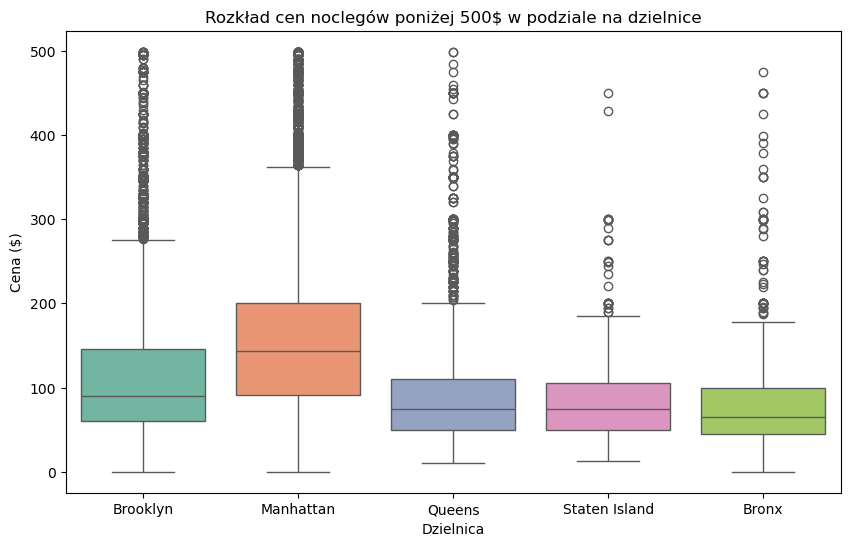

In [14]:
# Wizualizacja w Pythonie na podstawie przefiltrowanych danych
# Tworzymy wykres pudełkowy (boxplot) pokazujący rozkład cen noclegów w każdej z 5 głównych dzielnic. Filtrujemy dane, aby pokazać tylko ceny poniżej $500, co pozwala lepiej zobaczyć strukturę rozkładu cen w każdej dzielnicy, bez wpływu ekstremalnych wartości. Na osi X umieszczamy nazwy dzielnic, a na osi Y ceny noclegów. Dodajemy tytuł i etykiety osi, aby wykres był czytelny i informacyjny.
plt.figure(figsize=(10, 6))
# Filtrujemy ceny w Pandas tylko do celów wykresu (np. poniżej $500, żeby było widać strukturę)
sns.boxplot(
    data=df[df['price'] < 500], 
    x='neighbourhood_group', 
    y='price',
    hue='neighbourhood_group', 
    palette='Set2',
    legend=False
    )
plt.title('Rozkład cen noclegów poniżej 500$ w podziale na dzielnice')
plt.xlabel('Dzielnica')
plt.ylabel('Cena ($)')
plt.show()

In [15]:
# 5. Wykrywanie lokalnych outlierów cenowych
query_iqr = """
WITH Kwartyle AS (
    SELECT 
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price) AS q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price) AS q3
    FROM airbnb_clean
    WHERE price > 0
),
Progi AS (
    SELECT 
        q1, 
        q3,
        (q3 - q1) AS iqr,
        (q3 + 1.5 * (q3 - q1)) AS upper_bound
    FROM Kwartyle
)
SELECT 
    ROUND(p.q1, 2) AS "25% Kwartyl (Q1)",
    ROUND(p.q3, 2) AS "75% Kwartyl (Q3)",
    ROUND(p.iqr, 2) AS "Rozstęp IQR",
    ROUND(p.upper_bound, 2) AS "Statystyczny Próg Anomalii",
    (SELECT COUNT(*) FROM airbnb WHERE price > p.upper_bound) AS "Liczba Anomalii Górnych",
    ROUND((SELECT COUNT(*) FROM airbnb WHERE price > p.upper_bound) * 100.0 / (SELECT COUNT(*) FROM airbnb), 2) AS "Procent Anomalii %"
FROM Progi p;
"""

df_iqr_results = con.execute(query_iqr).df()
print("Wyniki analizy IQR dla cen:")
print(df_iqr_results.to_string())



Wyniki analizy IQR dla cen:
   25% Kwartyl (Q1)  75% Kwartyl (Q3)  Rozstęp IQR  Statystyczny Próg Anomalii  Liczba Anomalii Górnych  Procent Anomalii %
0             69.00            175.00       106.00                      334.00                     2972                6.08


In [16]:
# Obliczamy lokalną medianę dla każdej dzielnicy i szukamy ofert, które przebijają swój lokalny rynek w najbardziej absurdalny sposób.

query_local_outliers = """
WITH LokalneMediany AS (
    SELECT 
        id,
        name,
        neighbourhood_group,
        neighbourhood,
        price,
        MEDIAN(price) OVER (PARTITION BY neighbourhood_group) AS district_median
    FROM airbnb_clean
    WHERE price > 0
)
SELECT 
    id,
    name,
    neighbourhood_group,
    neighbourhood,
    price,
    ROUND(district_median, 0) AS lokalna_mediana,
    ROUND(price / district_median, 1) AS ile_razy_drozszy
FROM LokalneMediany
WHERE price > 1000
ORDER BY ile_razy_drozszy DESC
LIMIT 10;
"""

df_local = con.execute(query_local_outliers).df()
print("Top 10 ogłoszeń z ceną powyżej 1000$, pokazujące, ile razy są droższe od mediany w swojej dzielnicy:")
print(df_local.to_string())

Top 10 ogłoszeń z ceną powyżej 1000$, pokazujące, ile razy są droższe od mediany w swojej dzielnicy:
         id                                                name neighbourhood_group    neighbourhood  price  lokalna_mediana  ile_razy_drozszy
0   7003697                 Furnished room in Astoria apartment              Queens          Astoria  10000            75.00            133.30
1  13894339     Luxury 1 bedroom apt. -stunning Manhattan views            Brooklyn       Greenpoint  10000            90.00            111.10
2   2953058                                       Film Location            Brooklyn     Clinton Hill   8000            90.00             88.90
3  34895693                                Gem of east Flatbush            Brooklyn    East Flatbush   7500            90.00             83.30
4   2271504                    SUPER BOWL Brooklyn Duplex Apt!!            Brooklyn     Clinton Hill   6500            90.00             72.20
5   9528920                 Quiet, Clean,

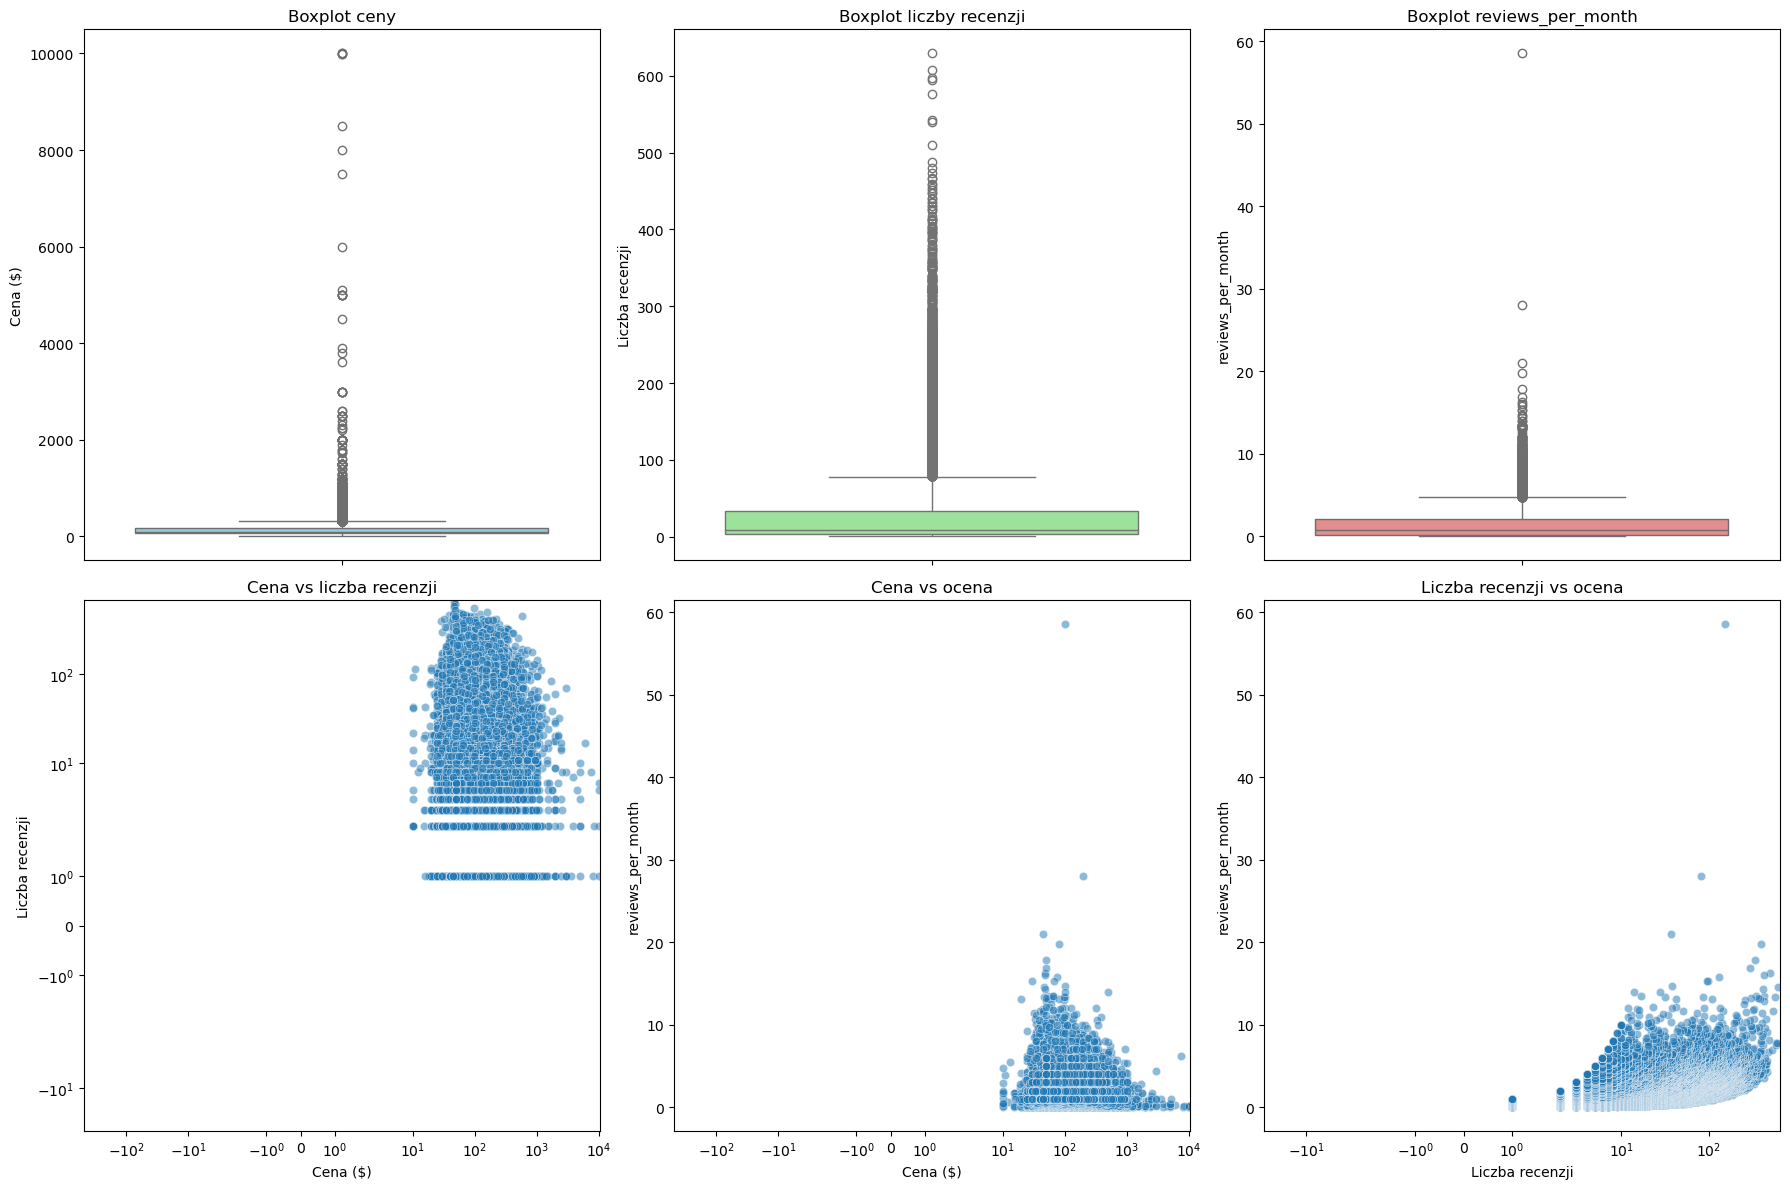

In [17]:
# Zastosujemy wykresy pudełkow (boxplot) i wykresy rozrzutu (scatter plot) aby zwizualizować outliery.

rating_col = None
if 'review_scores_rating' in df.columns:
    rating_col = 'review_scores_rating'
elif 'reviews_per_month' in df.columns:
    rating_col = 'reviews_per_month'
else:
    raise ValueError("Brak kolumny ocena/recenzji w df. Sprawdź dostępne kolumny.")

plot_df = df[['price', 'number_of_reviews', rating_col]].copy().dropna()
plot_df = plot_df[plot_df['price'] > 0]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

sns.boxplot(y=plot_df['price'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Boxplot ceny')
axes[0, 0].set_ylabel('Cena ($)')

sns.boxplot(y=plot_df['number_of_reviews'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Boxplot liczby recenzji')
axes[0, 1].set_ylabel('Liczba recenzji')

sns.boxplot(y=plot_df[rating_col], ax=axes[0, 2], color='lightcoral')
axes[0, 2].set_title(f'Boxplot {rating_col}')
axes[0, 2].set_ylabel(rating_col)

sns.scatterplot(data=plot_df, x='price', y='number_of_reviews', ax=axes[1, 0], alpha=0.5)
axes[1, 0].set_title('Cena vs liczba recenzji')
axes[1, 0].set_xscale('symlog')
axes[1, 0].set_yscale('symlog')
axes[1, 0].set_xlabel('Cena ($)')
axes[1, 0].set_ylabel('Liczba recenzji')

sns.scatterplot(data=plot_df, x='price', y=rating_col, ax=axes[1, 1], alpha=0.5)
axes[1, 1].set_title('Cena vs ocena')
axes[1, 1].set_xscale('symlog')
axes[1, 1].set_xlabel('Cena ($)')
axes[1, 1].set_ylabel(rating_col)

sns.scatterplot(data=plot_df, x='number_of_reviews', y=rating_col, ax=axes[1, 2], alpha=0.5)
axes[1, 2].set_title('Liczba recenzji vs ocena')
axes[1, 2].set_xscale('symlog')
axes[1, 2].set_xlabel('Liczba recenzji')
axes[1, 2].set_ylabel(rating_col)

plt.tight_layout()
plt.show()

_Oszustwo, luksus czy pomyłka? Kim są te wszystkie ludzie wystawiający te anomalne oferty i czy te rekordy są wiarygodne?_

_Dzielimy oferty na trzy kategorie cenowe:_ 

- A. _Ekstremalne anomalie (5000$+)_
  
- B. _Wysokie ceny / Outliery IQR (335-4999$)_
  
- C. _Normalny rynek (<335$)_

_Następnie dla każdej kategorii obliczamy liczbę ofert, średnią liczbę recenzji, średnią dostępność w dniach w roku oraz średnią minimalną liczbę nocy. To pozwoli nam zrozumieć, jak różnią się profile ofert w zależności od ich kategorii cenowej i czy istnieją jakieś charakterystyczne cechy dla każdej z tych kategorii._

In [19]:
# Analiza profilu ofert w podziale na kategorie cenowe

query_profile = """
SELECT 
    CASE 
        WHEN price >= 5000 THEN 'A. Ekstremalne anomalie (5000$+)'
        WHEN price >= 335 AND price < 5000 THEN 'B. Wysokie ceny / Outliery IQR (335$-4999$)'
        ELSE 'C. Normalny rynek (<335$)'
    END AS kategoria_cenowa,
    COUNT(*) AS liczba_ofert,
    ROUND(AVG(number_of_reviews), 1) AS sr_liczba_recenzji,
    ROUND(AVG(availability_365), 0) AS sr_dostępność_dni_w_roku,
    ROUND(AVG(minimum_nights), 1) AS sr_minimalna_liczba_nocy
FROM airbnb_clean
GROUP BY 1
ORDER BY 1;
"""

df_profile = con.execute(query_profile).df()
print("Profil ofert w podziale na kategorie cenowe:")
print(df_profile.to_string())

Profil ofert w podziale na kategorie cenowe:
                              kategoria_cenowa  liczba_ofert  sr_liczba_recenzji  sr_dostępność_dni_w_roku  sr_minimalna_liczba_nocy
0             A. Ekstremalne anomalie (5000$+)            26                2.70                    178.00                     22.10
1  B. Wysokie ceny / Outliery IQR (335$-4999$)          2946               13.00                    165.00                      8.30
2                    C. Normalny rynek (<335$)         45923               23.90                    109.00                      6.90


In [20]:
anomalous_1250 = df_airbnb_clean[df_airbnb_clean['minimum_nights'] == 1250].copy()
anomalous_1250_count = len(anomalous_1250)

print(f"Liczba ofert z wymaganym minimum_nights = 1250: {anomalous_1250_count}")
print(f"Liczba ofert z minimum_nights >= 1250: {len(df_airbnb_clean[df_airbnb_clean['minimum_nights'] >= 1250])}\n")

if anomalous_1250.empty:
    print("Brak ofert z wymaganym minimum_nights = 1250.")
else:
    print("Unikalne wartości minimum_nights w tych ofertach:", anomalous_1250['minimum_nights'].unique())
    print("Unikalne dostępności availability_365:", anomalous_1250['availability_365'].unique())
    print("\nPodsumowanie cen i dostępności:")
    print(anomalous_1250[['price', 'availability_365', 'number_of_reviews', 'reviews_per_month']].describe().to_string())

    print("\nRozkład po dzielnicach (neighbourhood_group):")
    print(anomalous_1250.groupby('neighbourhood_group').size().sort_values(ascending=False).to_string())

    print("\nTop 10 hostów z ofertami minimum_nights = 1250:")
    print(anomalous_1250.groupby(['host_id', 'host_name']).size().sort_values(ascending=False).head(10).to_string())

    print("\nPrzykładowe oferty:")
    print(
        anomalous_1250[
            ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood',
             'room_type', 'price', 'minimum_nights', 'availability_365', 'number_of_reviews',
             'reviews_per_month']
        ].head(20).to_string(index=False)
    )

Liczba ofert z wymaganym minimum_nights = 1250: 1
Liczba ofert z minimum_nights >= 1250: 1

Unikalne wartości minimum_nights w tych ofertach: [1250]
Unikalne dostępności availability_365: [365]

Podsumowanie cen i dostępności:
       price  availability_365  number_of_reviews  reviews_per_month
count   1.00              1.00               1.00               1.00
mean  180.00            365.00               2.00               0.03
std      NaN               NaN                NaN                NaN
min   180.00            365.00               2.00               0.03
25%   180.00            365.00               2.00               0.03
50%   180.00            365.00               2.00               0.03
75%   180.00            365.00               2.00               0.03
max   180.00            365.00               2.00               0.03

Rozkład po dzielnicach (neighbourhood_group):
neighbourhood_group
Manhattan    1

Top 10 hostów z ofertami minimum_nights = 1250:
host_id   host_name
1

***Otrzymane wyniki można zinterpretowac w taki sposób:***

*W grupie ekstremalnej ($5000+) zauważamy nagły spadek średniej liczby recenzji (często bliski zeru) oraz specyficzne anomalie w dostępności lub minimalnej liczbie nocy.*

*- Część tych ofert to błędy ludzkie (np. gospodarz wpisał o jedno zero za dużo).*

*- Część to celowe blokowanie kalendarza – gospodarze, którzy z jakiegoś powodu nie chcą wynajmować mieszkania w danym okresie, zamiast ukryć ofertę, ustawiają zaporową cenę 10 000$, przez co nikt jej nie zarezerwuje.*

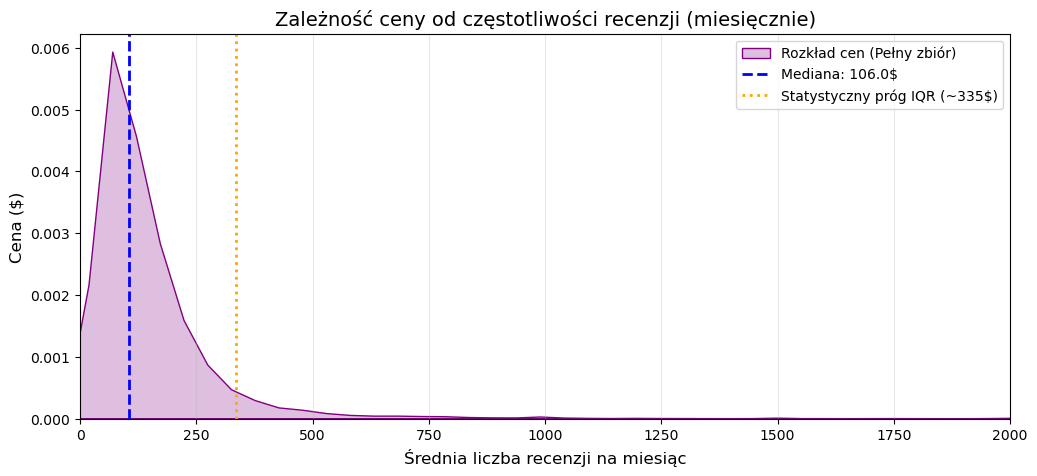

In [21]:
# Tworzymy wykres gęstości rozkładu (KDE Plot) aby pokazać tzw. "długi ogon" anomalii. Na osi X umieszczamy ceny, a na osi Y gęstość. Wypełniamy obszar pod krzywą, aby lepiej zobrazować rozkład cen. Dodajemy pionowe linie, które zaznaczają medianę cen oraz statystyczny próg anomalii, który wyliczyliśmy wcześniej (np. 335$). Tytuł wykresu i etykiety osi pomagają zrozumieć, co jest przedstawione na wykresie.


plt.figure(figsize=(12, 5))

# Rysujemy rozkład cen
sns.kdeplot(data=df, x='price', fill=True, color='purple', label='Rozkład cen (Pełny zbiór)')
plt.xlim(0, 2000) # Ograniczamy oś X tylko po to, by wykres był czytelny (anomalie uciekają do 10k)

# Zaznaczamy na wykresie punkty strategiczne, które wyliczyliśmy w SQL
plt.axvline(df['price'].median(), color='blue', linestyle='--', linewidth=2, label=f"Mediana: {df['price'].median()}$")
plt.axvline(335, color='orange', linestyle=':', linewidth=2, label="Statystyczny próg IQR (~335$)")

plt.title('Zależność ceny od częstotliwości recenzji (miesięcznie)', fontsize=14)
plt.xlabel('Średnia liczba recenzji na miesiąc', fontsize=12)
plt.ylabel('Cena ($)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='x', alpha=0.3)

plt.show()

***Krótkie sprawozdanie z analizy***

Analiza danych z `AB_NYC_2019.csv` ujawniła, że zbiór zawiera znaczącą liczbę wartości odstających i nietypowych wpisów, które wpływają na podstawowe metryki i interpretację wyników.

* Wyczyściliśmy dane, uwzględniając brakujące wartości w kolumnach `last_review` i `reviews_per_month`, co poprawiło spójność tabeli `airbnb_clean`.
* Zidentyfikowaliśmy silną asymetrię cenową: większość ofert mieści się w umiarkowanym przedziale, podczas gdy mniejsza grupa ekstremalnych cen tworzy długi ogon.
* Najdroższe oferty często mają niską liczbę recenzji, wysokie wymaganie minimalnej liczby nocy lub nietypową dostępność, co wskazuje na możliwe błędy, spam lub specjalne przypadki blokowania kalendarza.
* Lokalizacja i typ pokoju wpływają wyraźnie na wyniki: Manhattan oraz `Entire home/apt` mają wyższe ceny i większą zmienność niż reszta rynku.

***Wnioski:***
1. Anomalie cenowe powinny być analizowane osobno lub filtrowane przed budową modeli predykcyjnych.
2. Dobrą praktyką jest wprowadzenie walidacji ETL dla zakresów cen, `minimum_nights` oraz liczby recenzji.
3. Dalsza analiza może skupić się na segmentacji ofert oraz porównaniu wyników przed i po usunięciu outlierów.

In [5]:
!jupyter nbconvert Airbnb_New_York_City_2019.ipynb --to html --no-input --no-prompt --output Airbnb_New_York_City_2019.html

[NbConvertApp] Converting notebook Airbnb_New_York_City_2019.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 791231 bytes to Airbnb_New_York_City_2019.html
